### 7. High-gap influence analysis

## Input
- `data/processed/6_lexicon_affect.csv` 

Main questions:
1. Do posts with a higher count/proportion of high-gap words show larger expected_gap_mag?
2. Does high-gap word usage predict expected_gap_mag after controlling for post length, coverage, user and mh_flag?
3. Do high-gap words matter more than a matched set of non-high-gap affective words?
4. In an ablation test, does removing high-gap words reduce the L1-L2 gap at a post level, more than removing matched control words?

In [8]:
import ast
import json
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, mannwhitneyu, wilcoxon
import statsmodels.formula.api as smf
from tqdm.auto import tqdm

tqdm.pandas()

In [9]:
REPO_ROOT = Path.cwd()

# Try to use config if available; otherwise fall back to default folders.
processed_dir = REPO_ROOT / ".." / "data" / "processed"
tables_dir = REPO_ROOT / ".." / "reports" / "tables"
figures_dir = REPO_ROOT / ".." / "reports" / "figures"

try:
    import sys
    sys.path.insert(0, str(REPO_ROOT / ".." / "src"))
    from l2affect.utils.config import load_config, resolve  # type: ignore

    cfg = load_config(REPO_ROOT / ".." / "configs" / "config.yaml")
    processed_dir = resolve(cfg["paths"]["processed_dir"])
    tables_dir = resolve(cfg["paths"]["reports_tables_dir"])
    figures_dir = resolve(cfg["paths"]["reports_figures_dir"])
except Exception as e:
    print("Config not loaded (ok). Using default folders.")
    print("Reason:", e)

processed_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

processed_dir, tables_dir, figures_dir

(WindowsPath('C:/Users/hus44/Code/Directed-Reading-Project/data/processed'),
 WindowsPath('C:/Users/hus44/Code/Directed-Reading-Project/reports/tables'),
 WindowsPath('C:/Users/hus44/Code/Directed-Reading-Project/reports/figures'))

In [10]:
vad_path = processed_dir / "6_lexicon_affect.csv"
imbault_path = processed_dir / "1-imbault_gaps_va.csv"
high_gap_words_path = processed_dir / "top30_highgap_words_mh_enriched_top5.csv"

# Outputs
analysis_summary_path = processed_dir / "7_high_gap_influence_summary.csv"
ablation_summary_path = processed_dir / "7_high_gap_ablation_summary.csv"
post_level_ablation_path = processed_dir / "7_high_gap_ablation_postlevel.csv"

print("vad_path:", vad_path)
print("imbault_path:", imbault_path)
print("high_gap_words_path:", high_gap_words_path)

vad_path: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\6_lexicon_affect.csv
imbault_path: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\1-imbault_gaps_va.csv
high_gap_words_path: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\top30_highgap_words_mh_enriched_top5.csv


In [11]:
vad_posts = pd.read_csv(vad_path)
print(vad_posts.shape)
print(vad_posts.columns.tolist())
vad_posts.head(2)

(9168, 55)
['post_id', 'post_fullname', 'author', 'user_id', 'created_utc', 'created_at', 'title', 'selftext', 'subreddit', 'permalink', 'score', 'num_comments', 'source_file', 'text', 'tokens', 'n_tokens', 'n_chars', 'post_index', 'days_since_first', 'user_post_count', 'high_gap_count', 'high_gap_density', 'high_gap_gapmag_mean', 'high_gap_gapmag_max', 'high_gap_valence_mean_signed', 'high_gap_arousal_mean_signed', 'swear_count', 'swear_density', 'swear_present', 'swear_unique_count', 'swear_types', 'high_gap_swear_count', 'mh_sim_max', 'mh_sim_mean_top3', 'mh_best_seed_idx', 'mh_best_seed', 'mh_best_seed_sim', 'mh_flag', 'tokens_list', 'l1_expected_valence', 'l1_expected_arousal', 'l1_matched_items', 'l1_matched_token_count', 'l1_matched_token_prop', 'l1_matched_terms', 'l2_expected_valence', 'l2_expected_arousal', 'l2_matched_items', 'l2_matched_token_count', 'l2_matched_token_prop', 'l2_matched_terms', 'expected_gap_valence', 'expected_gap_arousal', 'expected_gap_mag', 'both_lexico

,post_id,post_fullname,author,user_id,created_utc,created_at,title,selftext,subreddit,permalink,...,l2_expected_valence,l2_expected_arousal,l2_matched_items,l2_matched_token_count,l2_matched_token_prop,l2_matched_terms,expected_gap_valence,expected_gap_arousal,expected_gap_mag,both_lexicons_matched
0,j4p7n0,t3_j4p7n0,Stylelike,000a672e1864051f,1.601769e+09,2020-10-03 23:42:25+00:00,Streak 2: First aids,I think that learn first aids is indispensable...,WriteStreakEN,/r/WriteStreakEN/comments/j4p7n0/streak_2_firs...,...,5.455000,5.127500,4,4,0.061538,"[""be"", ""important"", ""chance"", ""due""]",-0.542500,0.922500,1.070193,1
1,kk1866,t3_kk1866,Stylelike,000a672e1864051f,1.608912e+09,2020-12-25 16:01:26+00:00,Streak 1: Christmas and New Year.,"Firstly, I want to make it clear that I’m not ...",WriteStreakEN,/r/WriteStreakEN/comments/kk1866/streak_1_chri...,...,5.526667,4.888889,9,9,0.078261,"[""neutral"", ""day"", ""day"", ""dead"", ""special"", ""...",-0.252222,1.136667,1.164314,1


In [12]:
def parse_tokens_list(x):
    if isinstance(x, list):
        return [str(t).lower() for t in x]
    if pd.isna(x):
        return []
    if isinstance(x, str):
        x = x.strip()
        if not x:
            return []
        try:
            val = ast.literal_eval(x)
            if isinstance(val, list):
                return [str(t).lower() for t in val]
        except Exception:
            pass
    return []

vad_posts["tokens_list"] = vad_posts["tokens_list"].map(parse_tokens_list)

rename_map = {}
if "high_gap_count" in vad_posts.columns and "high_gap_token_count" not in vad_posts.columns:
    rename_map["high_gap_count"] = "high_gap_token_count"
if "high_gap_density" in vad_posts.columns and "high_gap_token_prop" not in vad_posts.columns:
    rename_map["high_gap_density"] = "high_gap_token_prop"

if rename_map:
    vad_posts = vad_posts.rename(columns=rename_map)

vad_posts["has_high_gap_word"] = (vad_posts["high_gap_token_count"] > 0).astype(int)

# With Imbault-for-both, these should match. Use one shared coverage variable.
if "matched_token_prop_used" not in vad_posts.columns:
    vad_posts["matched_token_prop_used"] = vad_posts["l1_matched_token_prop"]

required_cols = [
    "tokens_list",
    "n_tokens",
    "user_id",
    "l1_expected_valence",
    "l1_expected_arousal",
    "l1_matched_token_prop",
    "l2_expected_valence",
    "l2_expected_arousal",
    "expected_gap_valence",
    "expected_gap_arousal",
    "expected_gap_mag",
    "high_gap_token_count",
    "high_gap_token_prop",
]
missing = [c for c in required_cols if c not in vad_posts.columns]
if missing:
    raise ValueError(f"Notebook input file is missing required columns: {missing}")

vad_posts[[
    "n_tokens",
    "high_gap_token_count",
    "high_gap_token_prop",
    "expected_gap_mag"
]].head()

,n_tokens,high_gap_token_count,high_gap_token_prop,expected_gap_mag
0,65,1,0.015385,1.070193
1,115,1,0.008696,1.164314
2,75,1,0.013333,1.364763
3,398,2,0.005025,1.013025
4,8,1,0.125000,2.044771


In [13]:
high_gap_df = pd.read_csv(high_gap_words_path)
high_gap_words = set(
    high_gap_df["word"].dropna().astype(str).str.strip().str.lower()
)

def type_count_in_set(tokens, lex_set):
    toks = [str(t).lower() for t in tokens]
    return len(set(t for t in toks if t in lex_set))

if "high_gap_type_count" not in vad_posts.columns:
    vad_posts["high_gap_type_count"] = vad_posts["tokens_list"].map(
        lambda toks: type_count_in_set(toks, high_gap_words)
    )

print("n high-gap words:", len(high_gap_words))
vad_posts[[
    "high_gap_token_count",
    "high_gap_token_prop",
    "high_gap_type_count",
    "has_high_gap_word"
]].describe()

n high-gap words: 30


,high_gap_token_count,high_gap_token_prop,high_gap_type_count,has_high_gap_word
count,9168.000000,9168.000000,9168.000000,9168.0
mean,2.158159,0.014317,0.919284,1.0
std,1.795376,0.014462,0.768664,0.0
min,1.000000,0.000991,0.000000,1.0
25%,1.000000,0.006803,0.000000,1.0
50%,2.000000,0.010638,1.000000,1.0
75%,3.000000,0.017241,1.000000,1.0
max,27.000000,0.333333,5.000000,1.0


### Count and proportion analyses

This section asks whether posts with **more** high-gap words, or a **higher proportion** of them, tend to show larger `expected_gap_mag`.

In [14]:
corr_count = spearmanr(
    vad_posts["high_gap_token_count"],
    vad_posts["expected_gap_mag"],
    nan_policy="omit"
)
corr_prop = spearmanr(
    vad_posts["high_gap_token_prop"],
    vad_posts["expected_gap_mag"],
    nan_policy="omit"
)
corr_type = spearmanr(
    vad_posts["high_gap_type_count"],
    vad_posts["expected_gap_mag"],
    nan_policy="omit"
)

print("Spearman: high_gap_token_count vs expected_gap_mag")
print(corr_count)
print()
print("Spearman: high_gap_token_prop vs expected_gap_mag")
print(corr_prop)
print()
print("Spearman: high_gap_type_count vs expected_gap_mag")
print(corr_type)

Spearman: high_gap_token_count vs expected_gap_mag
SignificanceResult(statistic=np.float64(0.25332731297764477), pvalue=np.float64(3.1775787038509623e-134))

Spearman: high_gap_token_prop vs expected_gap_mag
SignificanceResult(statistic=np.float64(0.569157615393209), pvalue=np.float64(0.0))

Spearman: high_gap_type_count vs expected_gap_mag
SignificanceResult(statistic=np.float64(0.1442211938811139), pvalue=np.float64(8.389919242435281e-44))


In [15]:
count_summary = (
    vad_posts.groupby("high_gap_token_count", as_index=False)
    .agg(
        n_posts=("expected_gap_mag", "size"),
        mean_expected_gap_mag=("expected_gap_mag", "mean"),
        median_expected_gap_mag=("expected_gap_mag", "median"),
    )
    .sort_values("high_gap_token_count")
)

count_summary.head(15)

,high_gap_token_count,n_posts,mean_expected_gap_mag,median_expected_gap_mag
0,1,4343,0.990614,0.940217
1,2,2368,1.056332,1.008736
2,3,1131,1.135550,1.094313
3,4,579,1.151285,1.108429
4,5,329,1.197003,1.163719
5,6,160,1.253297,1.229504
6,7,95,1.211570,1.205753
7,8,50,1.270522,1.334538
8,9,34,1.280075,1.247137
9,10,29,1.267924,1.254630


In [16]:
prop_bins = pd.qcut(
    vad_posts["high_gap_token_prop"],
    q=5,
    duplicates="drop"
)

prop_summary = (
    vad_posts.assign(high_gap_prop_bin=prop_bins)
    .groupby("high_gap_prop_bin", as_index=False)
    .agg(
        n_posts=("expected_gap_mag", "size"),
        mean_high_gap_prop=("high_gap_token_prop", "mean"),
        mean_expected_gap_mag=("expected_gap_mag", "mean"),
        median_expected_gap_mag=("expected_gap_mag", "median"),
    )
)

prop_summary

,high_gap_prop_bin,n_posts,mean_high_gap_prop,mean_expected_gap_mag,median_expected_gap_mag
0,"(-9.00000000000011e-06, 0.00613]",1839,0.004484,0.830115,0.825485
1,"(0.00613, 0.00893]",1836,0.007504,0.915851,0.905402
2,"(0.00893, 0.0127]",1832,0.010725,1.018896,1.005963
3,"(0.0127, 0.0192]",1852,0.015695,1.119263,1.100487
4,"(0.0192, 0.333]",1809,0.033457,1.396498,1.345459


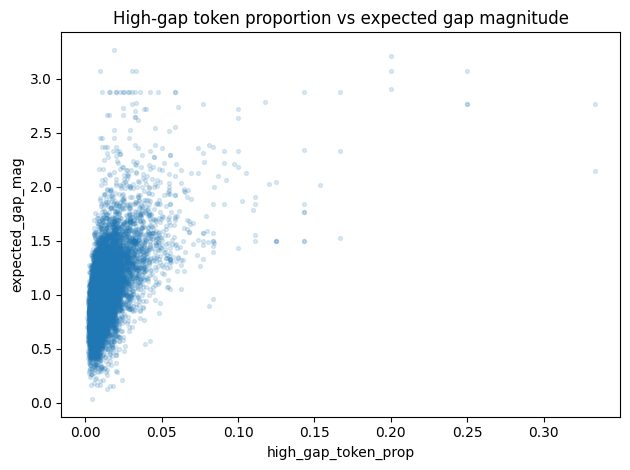

In [17]:
plt.figure()
plt.scatter(
    vad_posts["high_gap_token_prop"],
    vad_posts["expected_gap_mag"],
    alpha=0.15,
    s=8
)
plt.xlabel("high_gap_token_prop")
plt.ylabel("expected_gap_mag")
plt.title("High-gap token proportion vs expected gap magnitude")
plt.tight_layout()
plt.show()

### Regression with controls

These models test whether high-gap word usage predicts expected_gap_mag after controlling for:
- n_tokens
- shared lexicon coverage (matched_token_prop_used)
- clustering by user

In [19]:
reg_df = vad_posts.copy()
reg_df["log_n_tokens"] = np.log1p(reg_df["n_tokens"])
reg_df["user_id"] = reg_df["user_id"].astype(str)

if "mh_flag" in reg_df.columns:
    reg_df["mh_flag"] = reg_df["mh_flag"].astype(str)

formula_count = "expected_gap_mag ~ high_gap_token_count + log_n_tokens + matched_token_prop_used"
if "mh_flag" in reg_df.columns:
    formula_count += " + C(mh_flag)"

model_count = smf.ols(formula_count, data=reg_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["user_id"]}
)

print(model_count.summary())

                            OLS Regression Results                            
Dep. Variable:       expected_gap_mag   R-squared:                       0.427
Model:                            OLS   Adj. R-squared:                  0.427
Method:                 Least Squares   F-statistic:                     283.5
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          4.98e-145
Time:                        21:14:51   Log-Likelihood:                -909.14
No. Observations:                9168   AIC:                             1828.
Df Residuals:                    9163   BIC:                             1864.
Df Model:                           4                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [20]:
formula_prop = "expected_gap_mag ~ high_gap_token_prop + log_n_tokens + matched_token_prop_used"
if "mh_flag" in reg_df.columns:
    formula_prop += " + C(mh_flag)"

model_prop = smf.ols(formula_prop, data=reg_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["user_id"]}
)

print(model_prop.summary())

                            OLS Regression Results                            
Dep. Variable:       expected_gap_mag   R-squared:                       0.464
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     295.0
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          8.85e-149
Time:                        21:15:20   Log-Likelihood:                -610.45
No. Observations:                9168   AIC:                             1231.
Df Residuals:                    9163   BIC:                             1267.
Df Model:                           4                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

Controlling within-user

In [21]:
formula_count_fe = "expected_gap_mag ~ high_gap_token_count + log_n_tokens + matched_token_prop_used + C(user_id)"
if "mh_flag" in reg_df.columns:
    formula_count_fe += " + C(mh_flag)"

model_count_fe = smf.ols(formula_count_fe, data=reg_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["user_id"]}
)

print(model_count_fe.summary())

                            OLS Regression Results                            
Dep. Variable:       expected_gap_mag   R-squared:                       0.486
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     67.77
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.62e-48
Time:                        21:16:52   Log-Likelihood:                -411.10
No. Observations:                9168   AIC:                             2238.
Df Residuals:                    8460   BIC:                             7282.
Df Model:                         707                                         
Covariance Type:              cluster                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

c:\Users\hus44\AppData\Local\miniconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 707, but rank is 4
  warnings.warn('covariance of constraints does not have full '
